In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE

# load the data 

In [2]:
data = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
data.head()

,customerID,gender,Senior_Citizen,Is_Married,Dependents,tenure,Phone_Service,Dual,Internet_Service,Online_Security,...,Device_Protection,Tech_Support,Streaming_TV,Streaming_Movies,Contract,Paperless_Billing,Payment_Method,Monthly_Charges,Total_Charges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# EDA  & Cleaning

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customerID         7043 non-null   object 
 1   gender             7043 non-null   object 
 2   Senior_Citizen     7043 non-null   int64  
 3   Is_Married         7043 non-null   object 
 4   Dependents         7043 non-null   object 
 5   tenure             7043 non-null   int64  
 6   Phone_Service      7043 non-null   object 
 7   Dual               7043 non-null   object 
 8   Internet_Service   7043 non-null   object 
 9   Online_Security    7043 non-null   object 
 10  Online_Backup      7043 non-null   object 
 11  Device_Protection  7043 non-null   object 
 12  Tech_Support       7043 non-null   object 
 13  Streaming_TV       7043 non-null   object 
 14  Streaming_Movies   7043 non-null   object 
 15  Contract           7043 non-null   object 
 16  Paperless_Billing  7043 

In [4]:
#check balance 
print(data["Churn"].value_counts(normalize=True) *100)
print("------------------------------------------------------")
data["Churn"].value_counts()

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64
------------------------------------------------------


Churn
No     5174
Yes    1869
Name: count, dtype: int64

**we have the `customerID` which not useful at all**

In [5]:
df = data.copy()

df.drop("customerID",axis=1 ,inplace=True)

**change data types of the columns to meet the real value representation**

In [6]:
# the main problem now in Total_Charges
df["Total_Charges"] = pd.to_numeric(df["Total_Charges"], errors="coerce")

In [7]:
df["Total_Charges"].isna().sum()

np.int64(11)

**i think that i could drop these 11 rows but i also think  that i will calc near value from (tenure * Monthly_Charges)**

In [8]:
df.loc[df["Total_Charges"].isna(), "Total_Charges"] = (df["tenure"] * df["Monthly_Charges"])
df["Total_Charges"] = df["Total_Charges"].astype("float32")
df["Total_Charges"].isna().sum()

np.int64(0)

**now lets look  on the all non numeric columns**

In [9]:
df.columns = df.columns.str.strip()
df['Senior_Citizen'] = df['Senior_Citizen'].astype("category")
non_numeric_cols = df.select_dtypes(include=['category',"object"]).columns.tolist()

for col in non_numeric_cols:
    unique_vals = df[col].unique()
    print(f"--- {col} ---")
    print(unique_vals)
    print(f"unique values: {len(unique_vals)}\n")

--- gender ---
['Female' 'Male']
unique values: 2

--- Senior_Citizen ---
[0, 1]
Categories (2, int64): [0, 1]
unique values: 2

--- Is_Married ---
['Yes' 'No']
unique values: 2

--- Dependents ---
['No' 'Yes']
unique values: 2

--- Phone_Service ---
['No' 'Yes']
unique values: 2

--- Dual ---
['No phone service' 'No' 'Yes']
unique values: 3

--- Internet_Service ---
['DSL' 'Fiber optic' 'No']
unique values: 3

--- Online_Security ---
['No' 'Yes' 'No internet service']
unique values: 3

--- Online_Backup ---
['Yes' 'No' 'No internet service']
unique values: 3

--- Device_Protection ---
['No' 'Yes' 'No internet service']
unique values: 3

--- Tech_Support ---
['No' 'Yes' 'No internet service']
unique values: 3

--- Streaming_TV ---
['No' 'Yes' 'No internet service']
unique values: 3

--- Streaming_Movies ---
['No' 'Yes' 'No internet service']
unique values: 3

--- Contract ---
['Month-to-month' 'One year' 'Two year']
unique values: 3

--- Paperless_Billing ---
['Yes' 'No']
unique values

**from these info i think that we can categrize the columns**


In [10]:
#nums 
num_columns = ['tenure', 'Monthly_Charges', 'Total_Charges']
df[num_columns] = df[num_columns].astype('float64')

# binary coumns yes/no , male or female 
binary_yes_no = ['gender', 'Is_Married', 'Dependents', 'Phone_Service', 'Paperless_Billing']

for col in binary_yes_no:
    df[col] = df[col].map({'Yes': 1, 'No': 0, 'Female': 0, 'Male': 1})

# return it back 

df['Senior_Citizen'] = df['Senior_Citizen'].astype("int64")
binary_yes_no.append('Senior_Citizen')
# catigorical columns 
categorical_cols = [
    'Dual', 'Internet_Service', 'Online_Security', 'Online_Backup', 
    'Device_Protection', 'Tech_Support', 'Streaming_TV', 'Streaming_Movies',
    'Payment_Method']
df[categorical_cols] = df[categorical_cols].astype('category')

# Ordinal column: Contract >> the order matter 
contract_order = ["Month-to-month", "One year", "Two year"]
df['Contract'] = pd.Categorical(df['Contract'], categories=contract_order, ordered=True)

#Target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0}).astype('int64')


df.to_csv("cleaned_data.csv")
print(df.dtypes)

gender                  int64
Senior_Citizen          int64
Is_Married              int64
Dependents              int64
tenure                float64
Phone_Service           int64
Dual                 category
Internet_Service     category
Online_Security      category
Online_Backup        category
Device_Protection    category
Tech_Support         category
Streaming_TV         category
Streaming_Movies     category
Contract             category
Paperless_Billing       int64
Payment_Method       category
Monthly_Charges       float64
Total_Charges         float64
Churn                   int64
dtype: object


## lets visualize to get some insights from the data  

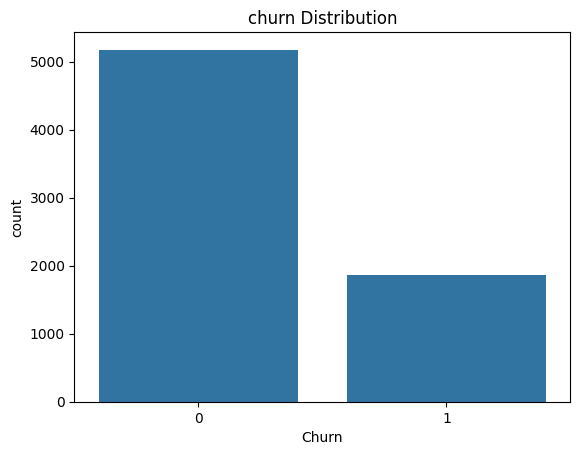

In [11]:
sns.countplot(x='Churn', data=df)
plt.title("churn Distribution")
plt.show() 

### Features vs churn

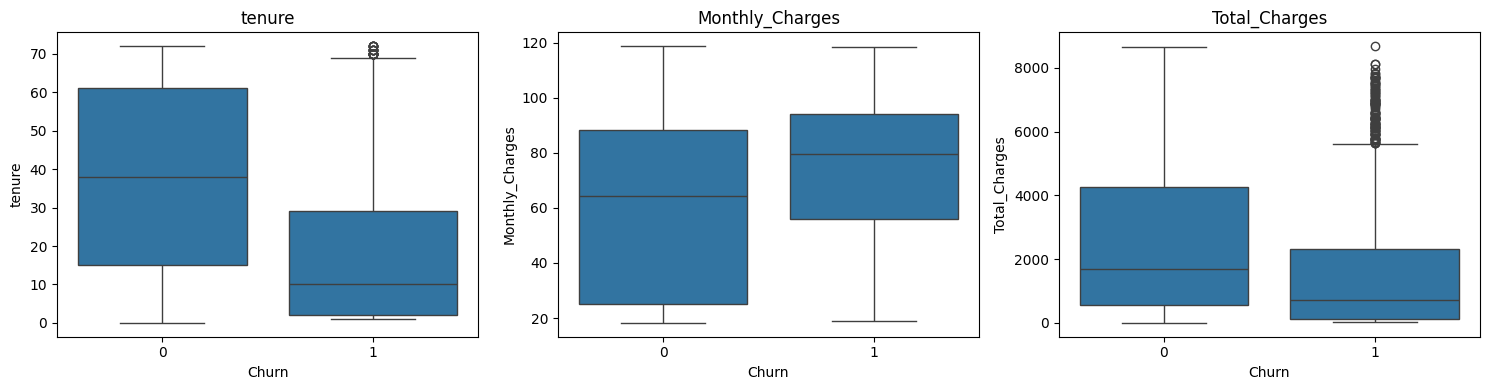

In [12]:
import math 
n_cols = 3
n_rows = math.ceil(len(num_columns) / n_cols)

plt.figure(figsize=(15, 4 * n_rows))

for i, col in enumerate(num_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x='Churn', y=col, data=df)
    plt.title(col)
    plt.tight_layout()

plt.show()

### insights
- low tenure people are moe likly to churn
- high monthly charge people are more likely to churn
- low total charge people are more likely to churn may be because they have a low tenure also this column has otliers


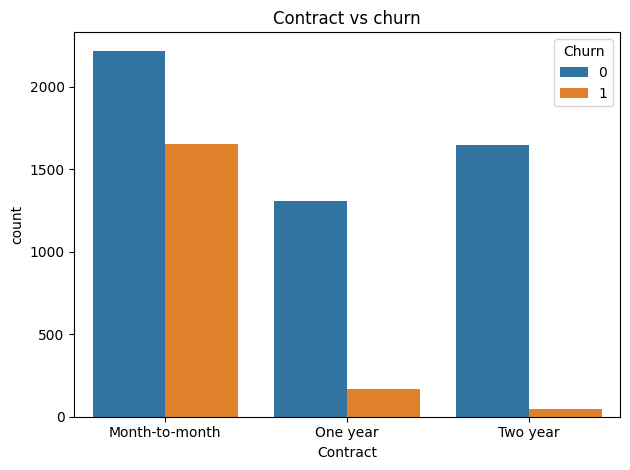

In [13]:
sns.countplot(data=df, x="Contract", hue='Churn')
plt.title('Contract vs churn')


plt.tight_layout()
plt.show()

**most churned people in month to month me be the are the new customers also**

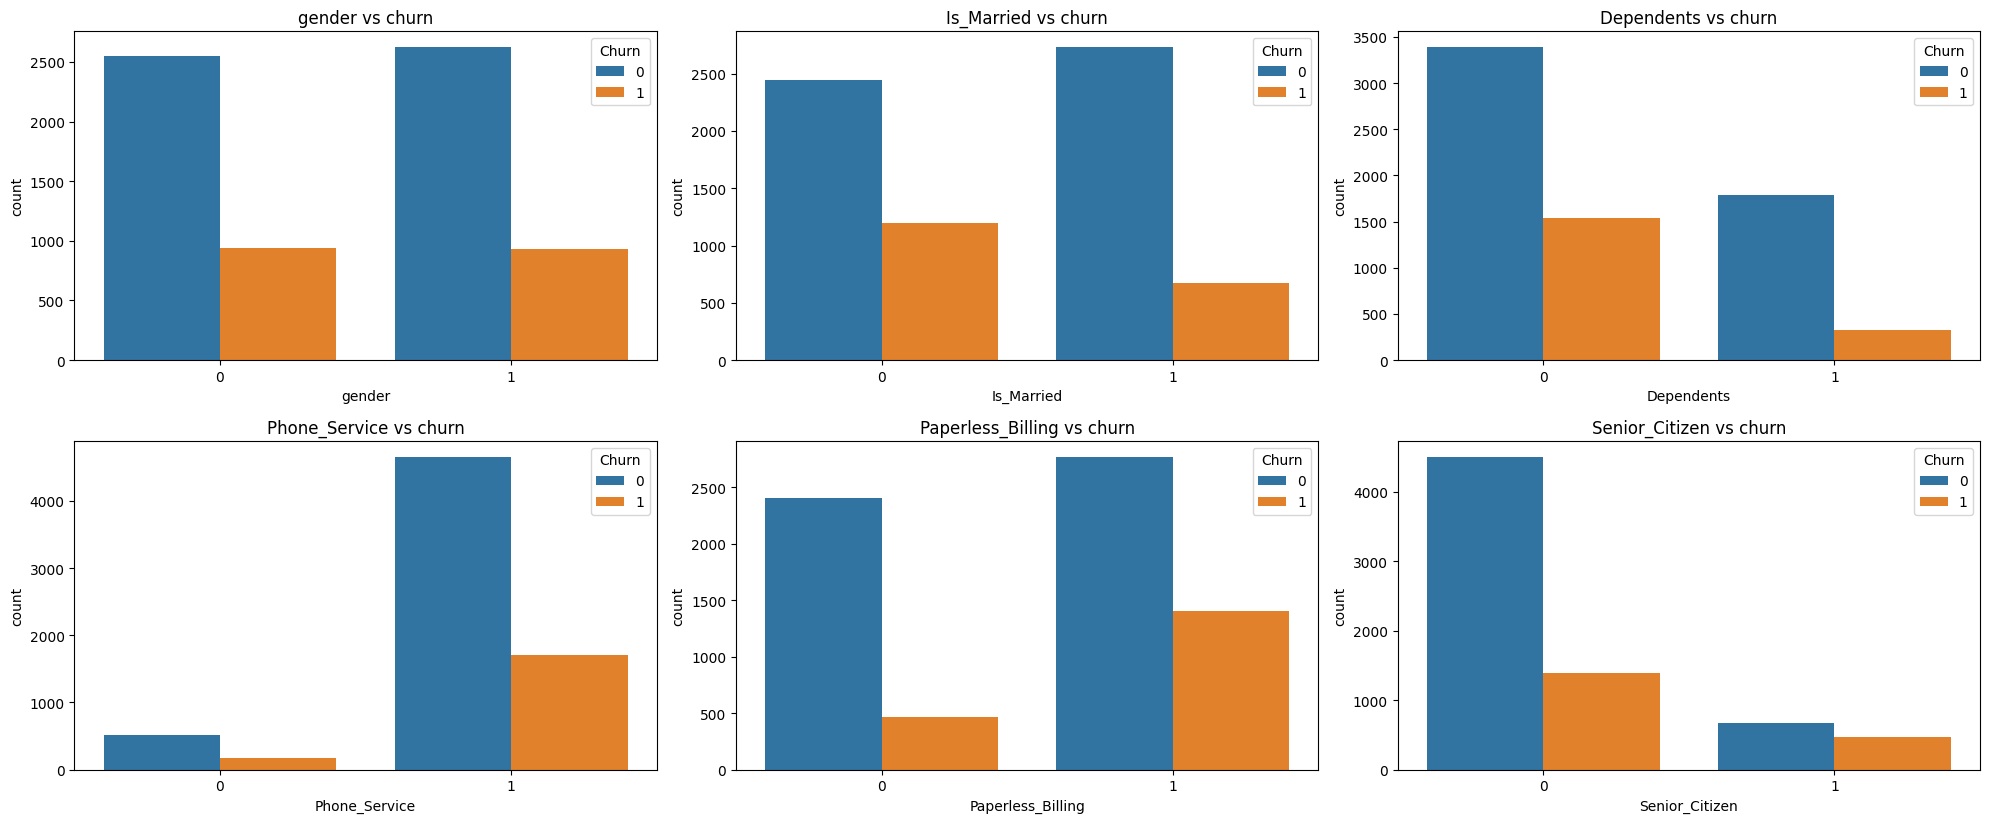

In [14]:
plt.figure(figsize=(20,12))

for i, col in enumerate(binary_yes_no):
    plt.subplot(3, 3, i+1)
    sns.countplot(data=df, x=col, hue='Churn')
    plt.title(f'{col} vs churn')
   

plt.tight_layout()
plt.show()

- Gender: No significant impact on churn.

- Not Married: Higher churn.

- No Dependents: Higher churn.

- Paperless Billing: Higher churn.

- Senior Citizens: Higher churn rate.

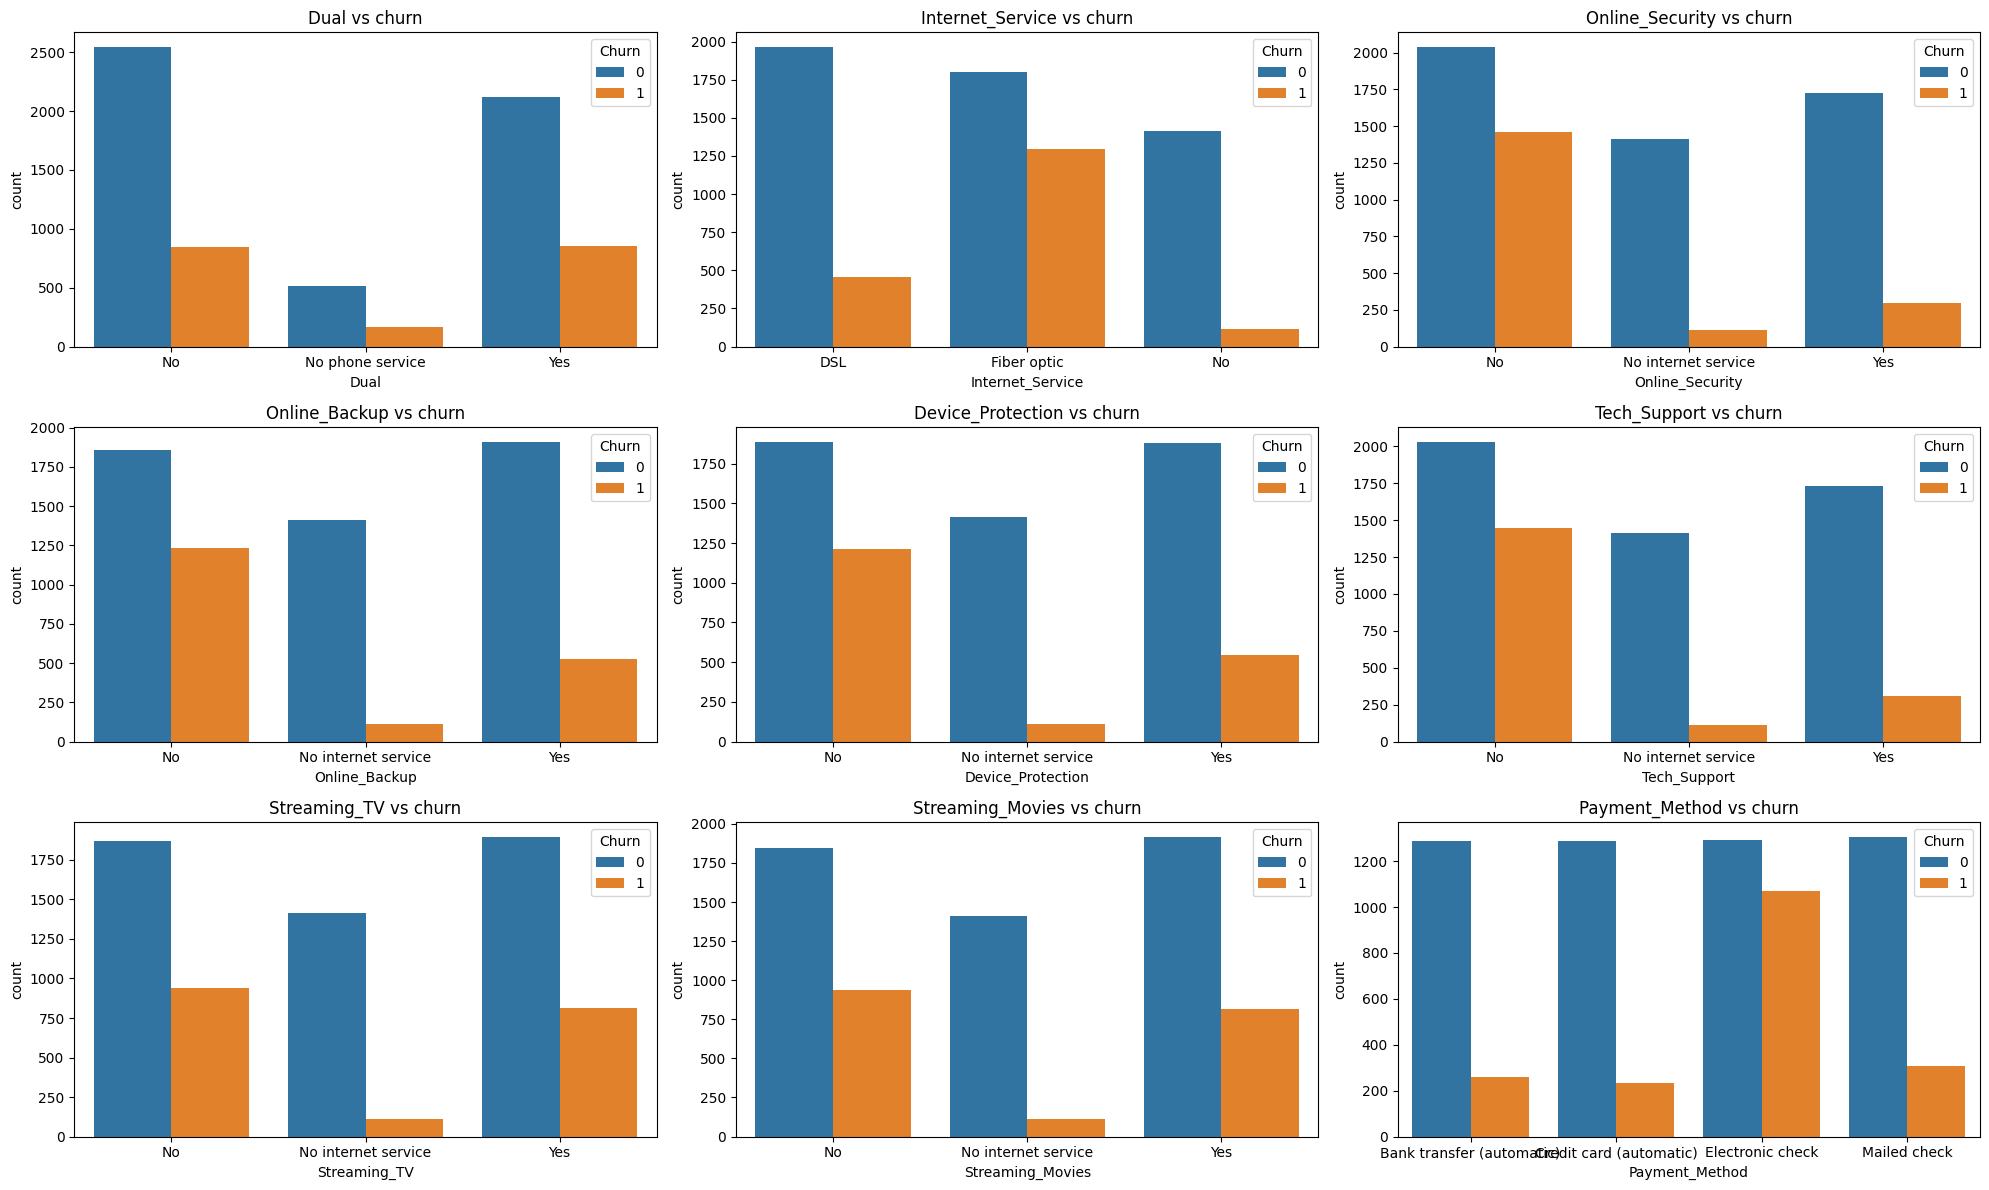

In [15]:
plt.figure(figsize=(20,12))
for i, col in enumerate(categorical_cols):
    plt.subplot(3, 3, i+1)
    sns.countplot(data=df, x=col, hue='Churn')
    plt.title(f'{col} vs churn')
   

plt.tight_layout()
plt.show()

### INSIGHTS 
- Dual Service: Slightly higher churn without dual service.

- Internet Service: Fiber optic users churn the most `may be they dont get what the expected ?`; no-internet users churn the least. 

- Online Security: No security → much higher churn.

- Online Backup: No backup → higher churn.

- Device Protection: No protection → higher churn.

- Tech Support: No tech support `whe should offer them an offers to subecribe` → significantly higher churn.

- Streaming TV/Movies: Minor impact on churn.

- Payment Method: Electronic check → highest churn `great problem here !!!!`; automatic payments → lower churn.

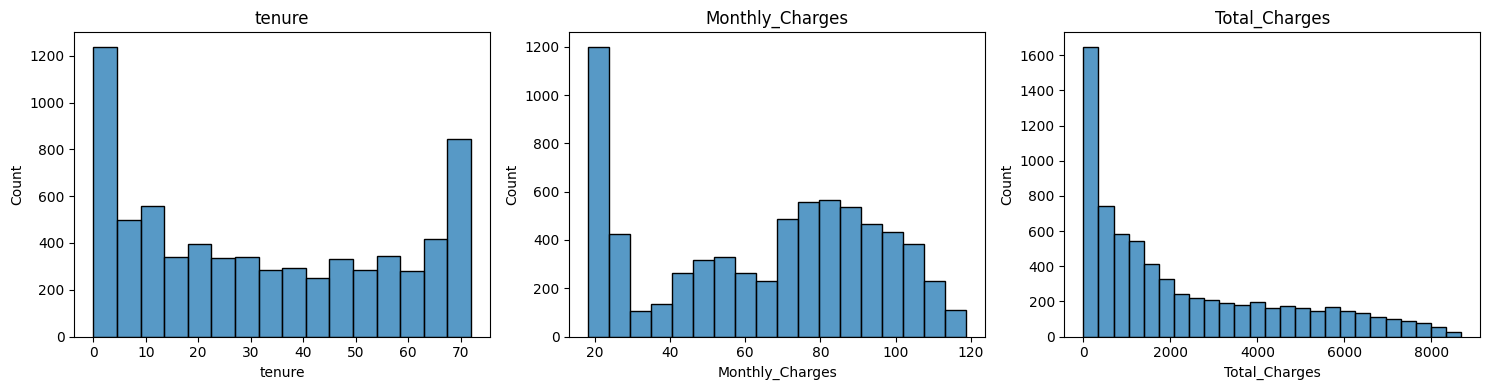

In [16]:
import math 
n_cols = 3
n_rows = math.ceil(len(num_columns) / n_cols)

plt.figure(figsize=(15, 4 * n_rows))

for i, col in enumerate(num_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot( x=col, data=df)
    plt.title(col)
    plt.tight_layout()

plt.show()

### observations
**`total chare has a high skeweed`**

**i will genrate another copy of the df called df2 with tenure devide into bins to the the best one later**

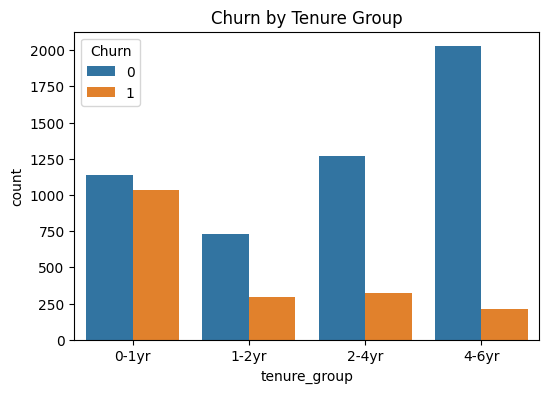

In [17]:
import numpy as np
df2=df.copy()

df2["tenure_group"] = pd.cut(
    df2["tenure"],
    bins=[0,12,24,48,72],
    labels=["0-1yr","1-2yr","2-4yr","4-6yr"]
)

plt.figure(figsize=(6,4))
sns.countplot(data=df2, x="tenure_group", hue="Churn")
plt.title("Churn by Tenure Group")
plt.show()

**as we saw before the new customers with less than one year with us has a very high churn rate**

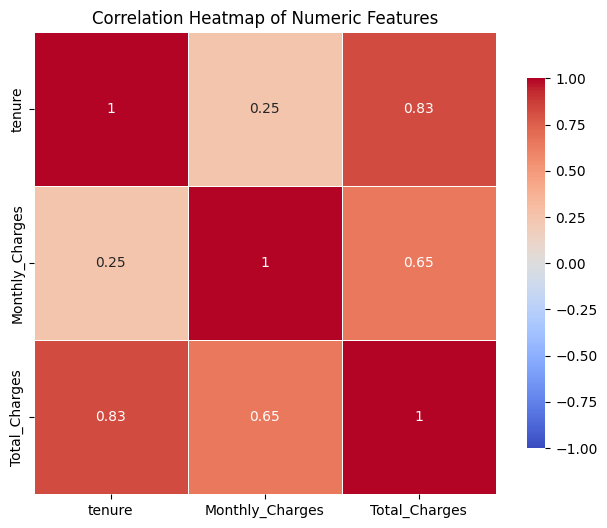

In [18]:
# check linear relations

numeric_cols = ['tenure', 'Monthly_Charges', 'Total_Charges']
corr_matrix = df[numeric_cols].corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, 
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

**there is  Multicollinearity between  tenure , total_charges >> may afect the model performance**

## build a base model first to see the result 

In [19]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

# stratify=y ensures that both the training and testing sets maintain the same proportion of class labels as the original dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,stratify=y,random_state=42)

In [20]:
# transform cat columns to nums 
num_cols = X.select_dtypes(include=['float64']).columns
binary_cols = X.select_dtypes(include=['int64']).columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns

# piplines of the data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),       
        ('bin', 'passthrough', binary_cols),       
        ('cat', OneHotEncoder(drop='first'), cat_cols)
    ]
)

In [21]:
from sklearn.linear_model import LogisticRegression

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced'))
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('bin', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

In [22]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

[[747 288]
 [ 81 293]]


**try same model with df2 and df2 without `total_charge`**

In [23]:
# model with binning tenure
X2 = df2.drop(["Churn","tenure"], axis=1)
y2 = df2["Churn"]

# model without total charges
X3 = df2.drop(["Churn","tenure","Total_Charges"], axis=1)
y3 = df2["Churn"]

# train-test split
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, stratify=y2, random_state=42)
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, stratify=y3, random_state=42)

# numeric & categorical columns
num_cols2 = X2.select_dtypes(include=['float64']).columns
binary_cols2 = X2.select_dtypes(include=['int64']).columns
cat_cols2 = X2.select_dtypes(include=['object', 'category']).columns

num_cols3 = X3.select_dtypes(include=['float64']).columns
binary_cols3 = X3.select_dtypes(include=['int64']).columns
cat_cols3 = X3.select_dtypes(include=['object', 'category']).columns


preprocessor2 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols2),       
        ('bin', 'passthrough', binary_cols2),       
        ('cat', OneHotEncoder(drop='first'), cat_cols2)
    ]
)

preprocessor3 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols3),       
        ('bin', 'passthrough', binary_cols3),       
        ('cat', OneHotEncoder(drop='first'), cat_cols3)
    ]
)

model2 = Pipeline(steps=[
    ('preprocessor', preprocessor2),
    ('classifier', LogisticRegression(class_weight='balanced'))
])

model3 = Pipeline(steps=[
    ('preprocessor', preprocessor3),
    ('classifier', LogisticRegression(class_weight='balanced'))])


In [24]:
# fit models
model2.fit(X2_train, y2_train)
model3.fit(X3_train, y3_train)

# predictions
y2_pred = model2.predict(X2_test)
y3_pred = model3.predict(X3_test)

# evaluate

print("first model")
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

print("Second model (with binning tenure)")
print(classification_report(y2_test, y2_pred))
print(confusion_matrix(y2_test, y2_pred))

print("Third model (binning tenure + removed total charges)")
print(classification_report(y3_test, y3_pred))
print(confusion_matrix(y3_test, y3_pred))

first model
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

[[747 288]
 [ 81 293]]
Second model (with binning tenure)
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

[[743 292]
 [ 81 293]]
Third model (binning tenure + removed total charges)
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                        

**no improvement will try another methods**

In [25]:
from imblearn.pipeline import Pipeline as ImbPipeline  # مهم: استخدام pipeline من imblearn

smote = SMOTE(random_state=42)

#pipeline
pipeline_smote_df = ImbPipeline(steps=[
    ('preprocessor', preprocessor),  
    ('smote', smote),
    ('classifier', LogisticRegression(class_weight='balanced'))
])


In [26]:
# train
pipeline_smote_df.fit(X_train, y_train)

# predict
y_pred_smote_df = pipeline_smote_df.predict(X_test)


# eval
print("orginal mode")
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

print("smote mode")
print(classification_report(y_test, y_pred_smote_df))
print(confusion_matrix(y_test, y_pred_smote_df))


orginal mode
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

[[747 288]
 [ 81 293]]
smote mode
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409

[[744 291]
 [ 75 299]]


## APPLAY GRID SEARCH TO DIFFERENT MODELS TO SEE THE BEST ONE

In [27]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


pipeline_smote_df = ImbPipeline(steps=[
    ('preprocessor', preprocessor),  
    ('classifier', LogisticRegression(class_weight='balanced'))
])
# aplay cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## logistic regression

In [28]:
param_grid_lr = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__penalty': ['l2'],
    'classifier__solver': ['lbfgs']
}

pipeline_lr = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000))
])

grid_lr = GridSearchCV(
    pipeline_lr,
    param_grid=param_grid_lr,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_lr.fit(X_train, y_train)

print("Best LR Params:", grid_lr.best_params_)
print("Best LR Score:", grid_lr.best_score_)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best LR Params: {'classifier__C': 10, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
Best LR Score: 0.8461959537729339


C:\Users\BS\anaconda3\envs\py_12\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


## Random Forest

In [29]:
param_grid_rf = {
    'classifier__n_estimators': [100, 300],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2]
}

pipeline_rf = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42))
])

grid_rf = GridSearchCV(
    pipeline_rf,
    param_grid=param_grid_rf,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, y_train)

print("Best RF Params:", grid_rf.best_params_)
print("Best RF Score:", grid_rf.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best RF Params: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 300}
Best RF Score: 0.8456399399822343


## XGboost

In [30]:
from xgboost import XGBClassifier

param_grid_xgb = {
    'classifier__n_estimators': [100, 300],
    'classifier__learning_rate': [0.01, 0.1],
    'classifier__max_depth': [3, 5],
    'classifier__subsample': [0.8, 1],
    'classifier__colsample_bytree': [0.8, 1]
}

pipeline_xgb = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    ))
])

grid_xgb = GridSearchCV(
    pipeline_xgb,
    param_grid=param_grid_xgb,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train, y_train)

print("Best XGB Params:", grid_xgb.best_params_)
print("Best XGB Score:", grid_xgb.best_score_)

Fitting 5 folds for each of 32 candidates, totalling 160 fits


C:\Users\BS\anaconda3\envs\py_12\Lib\site-packages\xgboost\training.py:200: UserWarning: [07:57:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best XGB Params: {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.01, 'classifier__max_depth': 5, 'classifier__n_estimators': 300, 'classifier__subsample': 0.8}
Best XGB Score: 0.8489789332180351


In [31]:
results = pd.DataFrame({
    "Model": ["Logistic", "RandomForest", "XGBoost"],
    "ROC_AUC": [
        grid_lr.best_score_,
        grid_rf.best_score_,
        grid_xgb.best_score_
    ]
}).sort_values(by="ROC_AUC", ascending=False)

print(results)

          Model   ROC_AUC
2       XGBoost  0.848979
0      Logistic  0.846196
1  RandomForest  0.845640


In [32]:
# best models so far
best_xgbost= grid_xgb.best_estimator_
best_randomf= grid_rf.best_estimator_

# Predict
y_pred_xg = grid_xgb.predict(X_test)
y_pred_rf = grid_rf.predict(X_test)

cm_xg = confusion_matrix(y_test, y_pred_xg)
cm_rf = confusion_matrix(y_test, y_pred_rf)


print("--------------------xgboost---------------------")
print(cm_xg)
print(classification_report(y_test, y_pred_xg))

print("--------------------random forest---------------------")
print(cm_rf)
print(classification_report(y_test, y_pred_rf))

--------------------xgboost---------------------
[[942  93]
 [181 193]]
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.52      0.58       374

    accuracy                           0.81      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.80      0.81      0.80      1409

--------------------random forest---------------------
[[805 230]
 [ 95 279]]
              precision    recall  f1-score   support

           0       0.89      0.78      0.83      1035
           1       0.55      0.75      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409



### Threshold Tuning

In [33]:
import numpy as np
from sklearn.metrics import precision_recall_curve

y_probs = best_xgbost.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

target_recall = 0.80
idx = np.argmin(np.abs(recalls - target_recall))
best_threshold = thresholds[idx]

print("Best Threshold:", best_threshold)

Best Threshold: 0.28263396


In [34]:
y_pred_new = (y_probs >= 0.28263396).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred_new))
print(classification_report(y_test, y_pred_new))

[[759 276]
 [ 75 299]]
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1035
           1       0.52      0.80      0.63       374

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409



## After threshold optimization
- **XGBoost achieved 80% recall for churned customers, outperforming Random Forest.**
- **Although overall accuracy slightly decreased, the improved recall ensures that more at-risk customers are identified.**
- **preventing customer loss is more valuable than minimizing false alarms.**
- **Therefore, XGBoost with optimized threshold was selected as the final model**

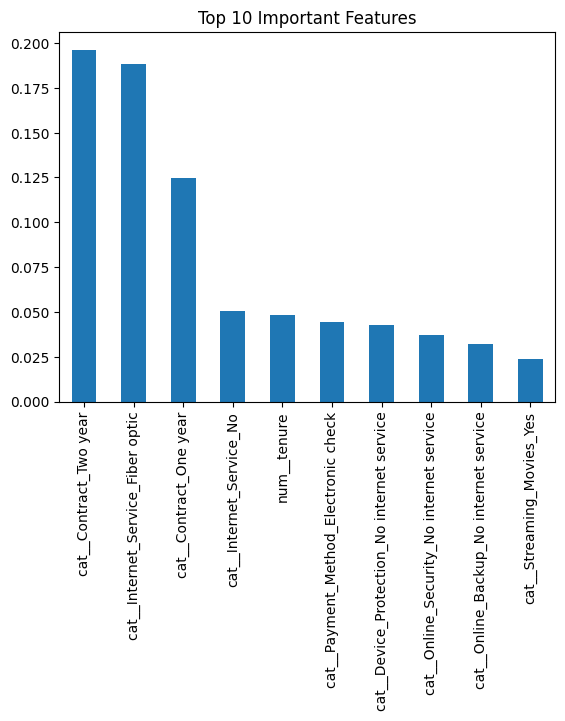

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

model = best_xgbost.named_steps['classifier']
importances = model.feature_importances_

feature_names = best_xgbost.named_steps['preprocessor'].get_feature_names_out()

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure()
feat_imp.head(10).plot(kind='bar')
plt.title("Top 10 Important Features")
plt.show()

## save the model 

In [36]:
import joblib
joblib.dump(best_xgbost, "churn_model.pkl")

['churn_model.pkl']

In [37]:
joblib.dump(preprocessor, 'preprocessor.pkl')

['preprocessor.pkl']

In [38]:
feature_names = preprocessor.get_feature_names_out()
joblib.dump(feature_names, 'feature_names.pkl')

['feature_names.pkl']